# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [ ]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from NM_TinyRNN.code.models import training_fast as speedrun
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import nested_cv_io as save_data
from NM_TinyRNN.code.models import nested_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

# let's test some code!
test_data_path = DATA_PATH / "WS16"
test_save_path  = './NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(speedrun)
reload(rnns)
# we use a trainer with ensemble model training across hyperparameters
trainer = speedrun.TrainerGPU(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1e-7],
                        energy_lambdas = [1e-1,0.01],
                        hebbian_lambdas = [1.0,0.1,0.01],
                        covariance_lambdas = [10.0,1.0,0.1])
model = rnns.TinyRNN(rnn_type = 'monoGRU',nonlinearity = 'relu', hidden_size = 2,
                     input_encoding='onehot',input_forced_choice = False)
dataset = ds.AB_Dataset(test_data_path, sequence_length = 64)
## You may test the trainer class to fit a single model:

final_state_dict, config, loss_dict = trainer.fit(model, dataset)


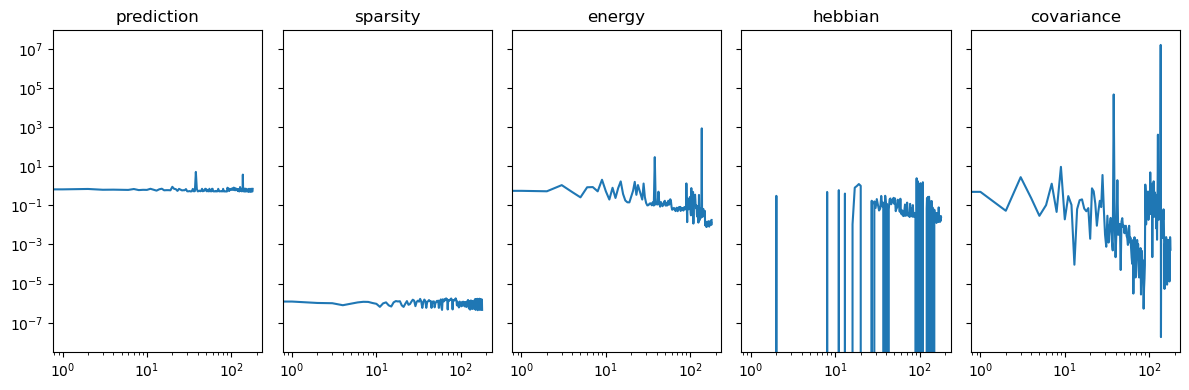

In [72]:
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].loglog(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

In [81]:
#Here we've got code to run all inner loops in parallel,  
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 10,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-5],
                                                 'energy_lambdas':[1.0,1e-1,1e-2],
                                                 'hebbian_lambdas':[1.0,1e-1,1e-2],
                                                 'covariance_lambdas':[1.0,1e-1,1e-2]} )
print([d['val_loss'] for d in outer_results['inner_results']])


[outer 1/10]  outer eval: 11 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu
Parallelizing 270 models on cpu


  0%|          | 0/1000 [00:00<?, ?it/s]

Parallelizing 270 models on cpu


  0%|          | 0/1000 [00:00<?, ?it/s] 1.02s/it]

Search complete. Best model index: 247. Val. loss: 0.48853132128715515
  Saved outer_fold_1/inner_fold_2 -> NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy/outer_fold_1/inner_fold_2  (val_loss=0.4885, eval_loss=0.6364)
Parallelizing 270 models on cpu


...

 59%|█████▉    | 589/1000 [09:55<06:40,  1.03it/s]

Search complete. Best model index: 123. Val. loss: 0.46188291907310486
  Saved outer_fold_1/inner_fold_6 -> NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy/outer_fold_1/inner_fold_6  (val_loss=0.4619, eval_loss=0.6530)


 62%|██████▏   | 620/1000 [10:25<06:23,  1.01s/it]


[0.4755893349647522, 0.4964976906776428, 0.48853132128715515, 0.44487264752388, 0.46578449010849, 0.47956371307373047, 0.46188291907310486, 0.5033248066902161, 0.4477735757827759]


Search complete. Best model index: 38. Val. loss: 0.46578449010849
  Saved outer_fold_1/inner_fold_4 -> NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy/outer_fold_1/inner_fold_4  (val_loss=0.4658, eval_loss=0.6413)
Search complete. Best model index: 243. Val. loss: 0.4477735757827759
  Saved outer_fold_1/inner_fold_8 -> NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy/outer_fold_1/inner_fold_8  (val_loss=0.4478, eval_loss=0.6407)


In [ ]:
reload(nested_jobs)
# for organising training of models, we aggregate an 'info_df', so we can keep track of paths and later also completion.
# this 'info_df' later becomes a scaffold pandas dataframe for analyses.

#see nested_jobs
test_df = nested_jobs.get_test_info_df()

test_df

#uncomment below to send jobs to HPC
test_df = nested_jobs.run_training(overwrite=True, test= True)

,subject_ID,outer_loop_n,model_type,hidden_size,nonlinearity,input_encoding,constraint,nm_size,nm_dim,nm_mode,model_id,save_path,data_path,completed
0,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,row,2_unit_monoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,1
1,WS16,1,monoGRU,2,relu,onehot,energy,1,1,row,2_unit_monoGRU_relu_onehot,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,1
2,WS16,2,monoGRU,2,relu,unipolar,energy,1,1,row,2_unit_monoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
3,WS16,2,monoGRU,2,relu,onehot,energy,1,1,row,2_unit_monoGRU_relu_onehot,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
4,WS16,3,monoGRU,2,relu,unipolar,energy,1,1,row,2_unit_monoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
5,WS16,3,monoGRU,2,relu,onehot,energy,1,1,row,2_unit_monoGRU_relu_onehot,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
6,WS16,4,monoGRU,2,relu,unipolar,energy,1,1,row,2_unit_monoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
7,WS16,4,monoGRU,2,relu,onehot,energy,1,1,row,2_unit_monoGRU_relu_onehot,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
8,WS16,5,monoGRU,2,relu,unipolar,energy,1,1,row,2_unit_monoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0
9,WS16,5,monoGRU,2,relu,onehot,energy,1,1,row,2_unit_monoGRU_relu_onehot,NM_TinyRNN/data/rnns/test/WS16/monoGRU/energy,NM_TinyRNN/data/AB_behaviour/WS16,0


Search complete. Best model index: 191. Val. loss: 0.5052576661109924
  Saved outer_fold_1/inner_fold_7 -> NM_TinyRNN/data/rnns/test/outer_fold_1/inner_fold_7  (val_loss=0.5053, eval_loss=0.6490)
Search complete. Best model index: 215. Val. loss: 0.4698154032230377
  Saved outer_fold_1/inner_fold_6 -> NM_TinyRNN/data/rnns/test/outer_fold_1/inner_fold_6  (val_loss=0.4698, eval_loss=0.6385)
Search complete. Best model index: 103. Val. loss: 0.44243696331977844
  Saved outer_fold_1/inner_fold_3 -> NM_TinyRNN/data/rnns/test/outer_fold_1/inner_fold_3  (val_loss=0.4424, eval_loss=0.6450)
Search complete. Best model index: 83. Val. loss: 0.479194700717926
  Saved outer_fold_1/inner_fold_5 -> NM_TinyRNN/data/rnns/test/outer_fold_1/inner_fold_5  (val_loss=0.4792, eval_loss=0.6433)
Search complete. Best model index: 7. Val. loss: 0.5106809735298157
  Saved outer_fold_1/inner_fold_1 -> NM_TinyRNN/data/rnns/test/outer_fold_1/inner_fold_1  (val_loss=0.5107, eval_loss=0.6496)
Search complete. Best m